# GAN Assignment – Building and Understanding Generative Adversarial Networks

This notebook covers all three parts of the GAN assignment. Part 1 deals with synthetic 2D data, Part 2.1 trains a DCGAN on the BloodMNIST dataset, Part 2.2 generates synthetic network traffic using the CICIDS 2017 dataset, and Part 2.3 trains a DCGAN on QuickDraw pizza sketches.

I've tried to keep things simple and well commented so it's easy to follow what's happening at each step.

## Imports

Getting all the libraries out of the way first. Most of this is standard PyTorch stuff plus a few extras for the specific datasets.

In [1]:
# standard libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# pytorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# for image stuff
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

# sklearn bits for part 2.2
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd

# set seeds so results are reproducible
torch.manual_seed(42)
np.random.seed(42)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


---
# Part 1 – Synthetic 2D Data

In this section I build a GAN from scratch and test it on two different 2D datasets: a sine wave and a mixture of Gaussians. I also modify the architecture and compare the results side by side.

## Task 1.1 – Generate the sine wave dataset

Making 2000 points with x values spread between -3 and 3. The y values follow a sine curve with a bit of Gaussian noise added in (std=0.1) to make it more realistic.

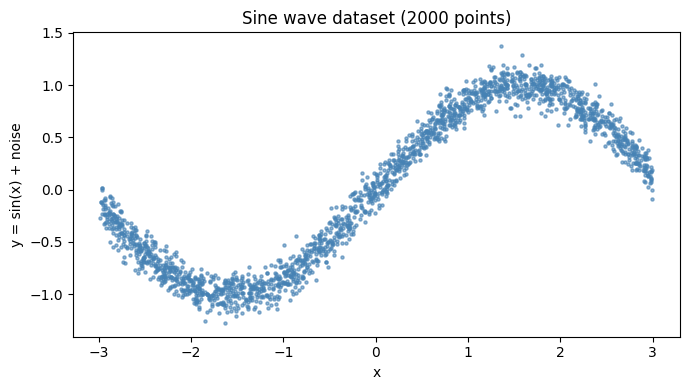

Dataset shape: (2000, 2)


In [2]:
# generate sine wave data
n_points = 2000
x = np.random.uniform(-3, 3, n_points)
y = np.sin(x) + np.random.normal(0, 0.1, n_points)  # add small noise

# stack into (n, 2) array and convert to tensor
sine_data = np.column_stack([x, y]).astype(np.float32)
sine_tensor = torch.tensor(sine_data)

# quick look at the dataset
plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=5, color='steelblue', alpha=0.6)
plt.title('Sine wave dataset (2000 points)')
plt.xlabel('x')
plt.ylabel('y = sin(x) + noise')
plt.tight_layout()
plt.show()

print('Dataset shape:', sine_data.shape)

## Task 1.2 – Build and train a simple GAN on the sine wave

Both the generator and discriminator are 2-layer MLPs with hidden size 128. Generator uses ReLU activations and the discriminator has a sigmoid at the end to output a probability. Training runs for 2000 iterations.

In [3]:
# define the generator - takes 2D noise and outputs 2D points
class Generator(nn.Module):
    def __init__(self, input_dim=2, hidden=128, output_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )

    def forward(self, z):
        return self.model(z)


# define the discriminator - takes 2D point and outputs probability of being real
class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden=128):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()  # output is a probability
        )

    def forward(self, x):
        return self.model(x)

In [4]:
# training function - takes a dataset tensor and trains a GAN on it
def train_gan(data_tensor, n_iters=2000, batch_size=64, lr=0.0002,
              use_leaky=False, noise_dim=2):
    '''
    Trains a simple GAN on 2D data.
    use_leaky=True switches ReLU to LeakyReLU(0.2) in both networks.
    Returns trained generator and loss history.
    '''

    # pick activation based on flag
    act = nn.LeakyReLU(0.2) if use_leaky else nn.ReLU()

    # build generator with chosen activation
    gen = nn.Sequential(
        nn.Linear(noise_dim, 128), act,
        nn.Linear(128, 128), act,
        nn.Linear(128, 2)
    ).to(device)

    # build discriminator with chosen activation
    disc = nn.Sequential(
        nn.Linear(2, 128), act,
        nn.Linear(128, 128), act,
        nn.Linear(128, 1), nn.Sigmoid()
    ).to(device)

    # optimisers
    opt_g = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    criterion = nn.BCELoss()

    # make a dataloader
    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    g_losses = []
    d_losses = []

    # training loop
    for iteration in range(n_iters):
        # grab a random batch of real data
        real_batch = data_tensor[torch.randint(0, len(data_tensor), (batch_size,))].to(device)

        # ---- train discriminator ----
        disc.zero_grad()

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # loss on real samples
        d_real = disc(real_batch)
        loss_real = criterion(d_real, real_labels)

        # loss on fake samples
        z = torch.randn(batch_size, noise_dim).to(device)
        fake = gen(z).detach()  # detach so we don't backprop through generator here
        d_fake = disc(fake)
        loss_fake = criterion(d_fake, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        opt_d.step()

        # ---- train generator ----
        gen.zero_grad()

        z = torch.randn(batch_size, noise_dim).to(device)
        fake = gen(z)
        d_out = disc(fake)

        # generator wants discriminator to think fakes are real
        g_loss = criterion(d_out, real_labels)
        g_loss.backward()
        opt_g.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    return gen, disc, g_losses, d_losses

Training GAN on sine wave data...
Done!


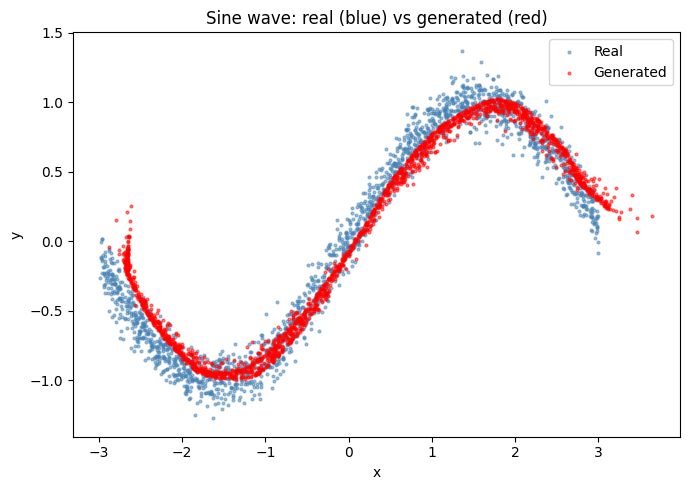

In [5]:
# train on sine wave data
print('Training GAN on sine wave data...')
gen_sine, disc_sine, g_loss_sine, d_loss_sine = train_gan(sine_tensor)
print('Done!')

# generate some fake samples
with torch.no_grad():
    z = torch.randn(2000, 2).to(device)
    fake_sine = gen_sine(z).cpu().numpy()

# scatter plot: real vs generated
plt.figure(figsize=(7, 5))
plt.scatter(sine_data[:, 0], sine_data[:, 1], s=4, color='steelblue', alpha=0.5, label='Real')
plt.scatter(fake_sine[:, 0], fake_sine[:, 1], s=4, color='red', alpha=0.5, label='Generated')
plt.title('Sine wave: real (blue) vs generated (red)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

## Task 1.3 – Mixture of Gaussians

Creating a dataset with 3 Gaussian clusters centred at (-2, 2), (0, 0) and (2, -2). Each cluster has the same covariance. I'll use this to see how well the GAN handles a multi-modal distribution, which is more challenging than the single sine curve.

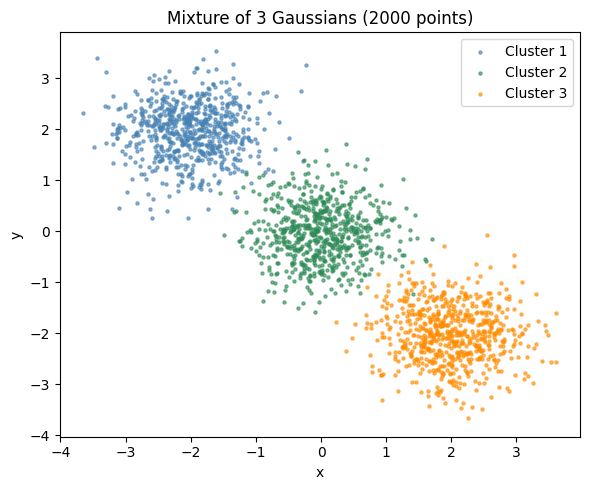

Gaussian dataset shape: (1998, 2)


In [6]:
# create mixture of 3 gaussians
centres = [(-2, 2), (0, 0), (2, -2)]
cov = [[0.3, 0], [0, 0.3]]

gauss_samples = []
for centre in centres:
    # sample roughly equal number of points from each cluster
    pts = np.random.multivariate_normal(centre, cov, size=n_points // 3)
    gauss_samples.append(pts)

gauss_data = np.vstack(gauss_samples).astype(np.float32)
gauss_tensor = torch.tensor(gauss_data)

# visualise the dataset
plt.figure(figsize=(6, 5))
colors = ['steelblue', 'seagreen', 'darkorange']
for i, pts in enumerate(gauss_samples):
    plt.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.6, color=colors[i], label=f'Cluster {i+1}')
plt.title('Mixture of 3 Gaussians (2000 points)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

print('Gaussian dataset shape:', gauss_data.shape)

Training GAN on mixture of Gaussians...
Done!


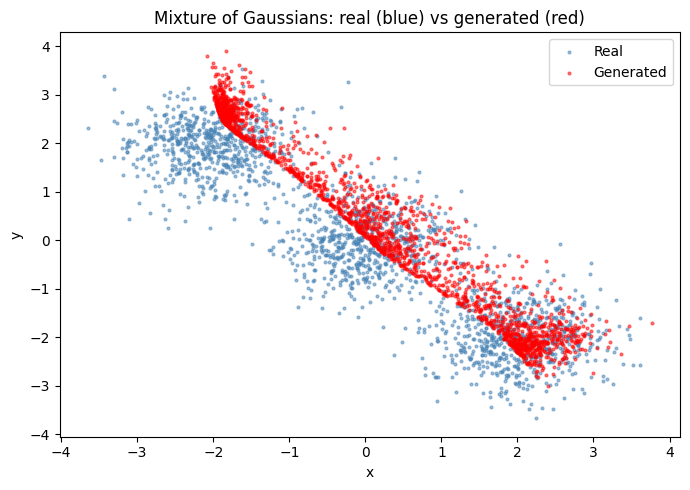

In [7]:
# train the same GAN on the gaussian mixture
print('Training GAN on mixture of Gaussians...')
gen_gauss, disc_gauss, g_loss_gauss, d_loss_gauss = train_gan(gauss_tensor)
print('Done!')

# generate fake samples
with torch.no_grad():
    z = torch.randn(2000, 2).to(device)
    fake_gauss = gen_gauss(z).cpu().numpy()

# plot real vs generated
plt.figure(figsize=(7, 5))
plt.scatter(gauss_data[:, 0], gauss_data[:, 1], s=4, color='steelblue', alpha=0.5, label='Real')
plt.scatter(fake_gauss[:, 0], fake_gauss[:, 1], s=4, color='red', alpha=0.5, label='Generated')
plt.title('Mixture of Gaussians: real (blue) vs generated (red)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

## Task 1.4 – Modified GAN with LeakyReLU

Switching all ReLU activations to LeakyReLU(0.2). The reason for trying this is that LeakyReLU allows a small gradient even for negative inputs (the slope is 0.2 instead of 0), which helps the discriminator pass gradients back more effectively and can reduce the problem of dead neurons. Retraining on the mixture of Gaussians to see if it makes a difference.

In [8]:
# retrain with leaky relu on the gaussian mixture
print('Training modified GAN (LeakyReLU) on mixture of Gaussians...')
gen_leaky, disc_leaky, g_loss_leaky, d_loss_leaky = train_gan(gauss_tensor, use_leaky=True)
print('Done!')

# generate from modified generator
with torch.no_grad():
    z = torch.randn(2000, 2).to(device)
    fake_leaky = gen_leaky(z).cpu().numpy()

Training modified GAN (LeakyReLU) on mixture of Gaussians...
Done!


## Task 1.5 – Three-way comparison

Showing all three side by side: the real data, the original GAN (ReLU), and the modified GAN (LeakyReLU). This makes it easy to see which architecture captures the multi-modal structure better.

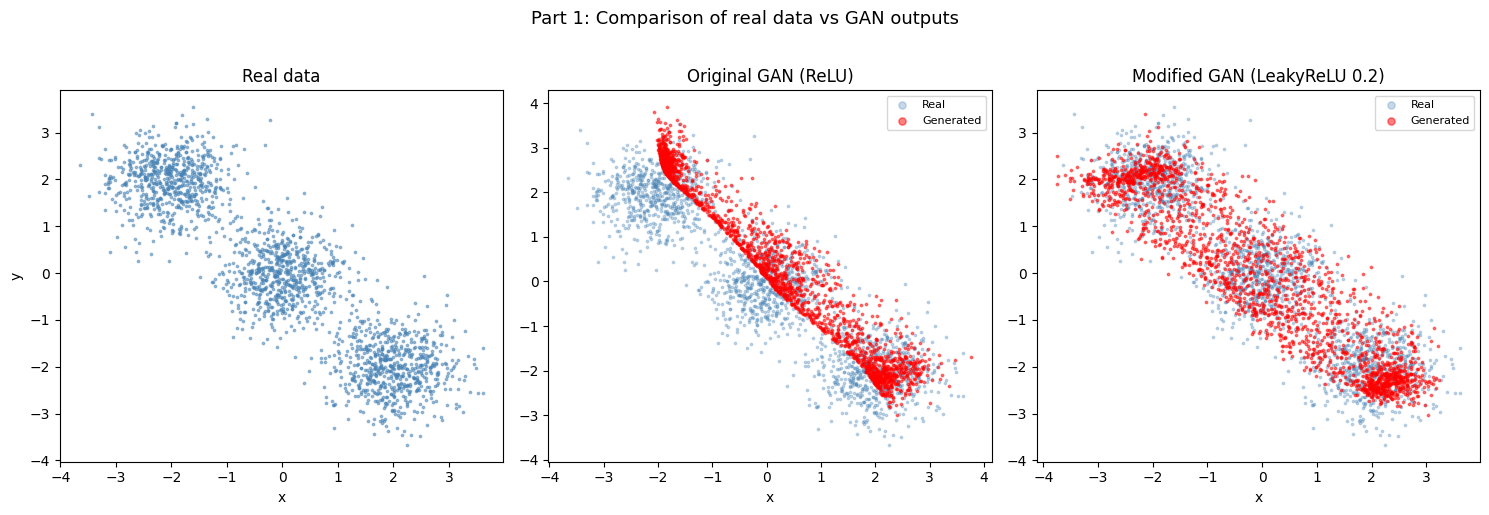

In [9]:
# three plots side by side: real | original GAN | modified GAN
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# real data
axes[0].scatter(gauss_data[:, 0], gauss_data[:, 1], s=3, color='steelblue', alpha=0.5)
axes[0].set_title('Real data')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# original GAN with ReLU
axes[1].scatter(gauss_data[:, 0], gauss_data[:, 1], s=3, color='steelblue', alpha=0.3, label='Real')
axes[1].scatter(fake_gauss[:, 0], fake_gauss[:, 1], s=3, color='red', alpha=0.5, label='Generated')
axes[1].set_title('Original GAN (ReLU)')
axes[1].set_xlabel('x')
axes[1].legend(markerscale=3, fontsize=8)

# modified GAN with LeakyReLU
axes[2].scatter(gauss_data[:, 0], gauss_data[:, 1], s=3, color='steelblue', alpha=0.3, label='Real')
axes[2].scatter(fake_leaky[:, 0], fake_leaky[:, 1], s=3, color='red', alpha=0.5, label='Generated')
axes[2].set_title('Modified GAN (LeakyReLU 0.2)')
axes[2].set_xlabel('x')
axes[2].legend(markerscale=3, fontsize=8)

plt.suptitle('Part 1: Comparison of real data vs GAN outputs', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


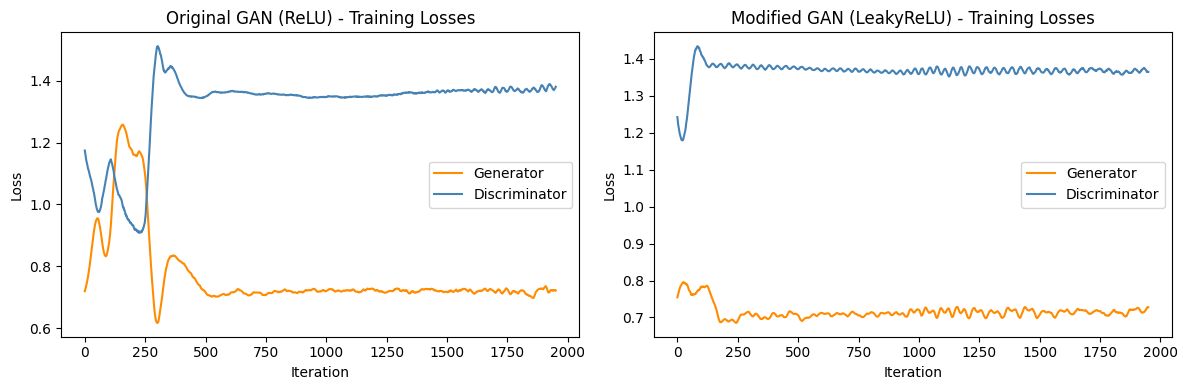

In [10]:
# also plot the training losses to see how stable training was
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# smooth the losses a bit for readability
def smooth(vals, w=50):
    return np.convolve(vals, np.ones(w)/w, mode='valid')

axes[0].plot(smooth(g_loss_gauss), label='Generator', color='darkorange')
axes[0].plot(smooth(d_loss_gauss), label='Discriminator', color='steelblue')
axes[0].set_title('Original GAN (ReLU) - Training Losses')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(smooth(g_loss_leaky), label='Generator', color='darkorange')
axes[1].plot(smooth(d_loss_leaky), label='Discriminator', color='steelblue')
axes[1].set_title('Modified GAN (LeakyReLU) - Training Losses')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# Part 2.1 – BloodMNIST (DCGAN)

In this part I train a Deep Convolutional GAN on the BloodMNIST dataset which contains microscope images of different blood cell types. The goal is to generate realistic-looking synthetic blood cell images and measure quality using FID.

## Setup – Load BloodMNIST

Using the medmnist library to load the data. Normalising images from [0, 255] to [-1, 1] because the generator uses tanh at the output, which has range [-1, 1].

In [11]:
# install medmnist if not already available
try:
    import medmnist
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'medmnist', '-q'])
    import medmnist

from medmnist import BloodMNIST
from medmnist import INFO

# check the dataset info
info = INFO['bloodmnist']
print('Number of colour channels:', info['n_channels'])
print('Task:', info['task'])
print('Number of classes (blood cell types): 8')


Number of colour channels: 3
Task: multi-class
Number of classes (blood cell types): 8


In [12]:
# transforms: convert to tensor and normalise to [-1, 1]
transform_blood = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # maps [0,1] -> [-1,1]
])

# load training set
blood_train = BloodMNIST(split='train', transform=transform_blood, download=True)
blood_loader = DataLoader(blood_train, batch_size=64, shuffle=True, num_workers=0)

print('Training set size:', len(blood_train))
print('Image shape:', blood_train[0][0].shape)

100%|██████████| 35.5M/35.5M [00:23<00:00, 1.50MB/s]


Training set size: 11959
Image shape: torch.Size([3, 28, 28])


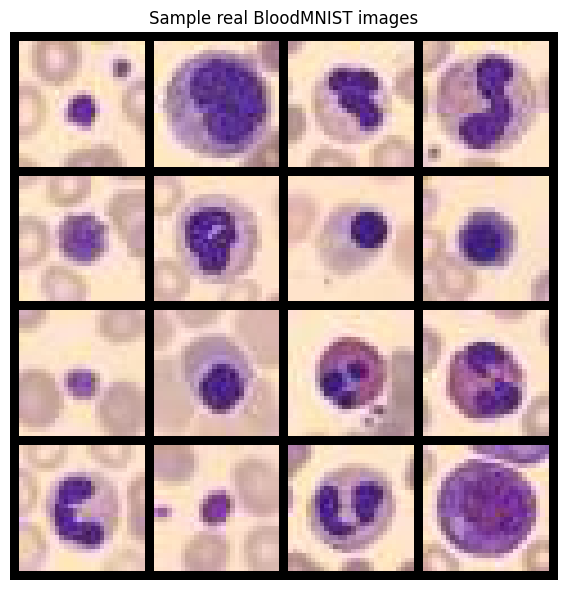


Class distribution:
  Class 0: 852 images
  Class 1: 2181 images
  Class 2: 1085 images
  Class 3: 2026 images
  Class 4: 849 images
  Class 5: 993 images
  Class 6: 2330 images
  Class 7: 1643 images


In [13]:
# have a look at some real images to understand what we're working with
sample_imgs = torch.stack([blood_train[i][0] for i in range(16)])
grid = vutils.make_grid(sample_imgs, nrow=4, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title('Sample real BloodMNIST images')
plt.axis('off')
plt.tight_layout()
plt.show()

# check class distribution
labels_all = [blood_train[i][1].item() for i in range(len(blood_train))]
unique, counts = np.unique(labels_all, return_counts=True)
print('\nClass distribution:')
for cls, cnt in zip(unique, counts):
    print(f'  Class {cls}: {cnt} images')

## Build the DCGAN

DCGAN uses convolutional layers instead of fully connected ones, which works much better for images. The generator uses transposed convolutions to upsample from a 100-dimensional noise vector up to a 28x28 RGB image. The discriminator does the reverse - downsampling to a single probability value. BatchNorm is used in both to stabilise training.

In [14]:
# generator: noise (100,) -> image (3, 28, 28)
# uses ConvTranspose2d to upsample step by step
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # start from 1x1 and upsample
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 4x4
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 8x8
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 16x16
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=3, bias=False),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        # z shape: (batch, latent_dim, 1, 1)
        return self.net(z)


# discriminator: image (3, 28, 28) -> probability
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 3x3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 3x3 -> 1x1   (changed kernel from 4 to 3)
            nn.Conv2d(256, 1, kernel_size=3, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img).view(-1, 1)


# initialise models
dc_gen = DCGenerator(latent_dim=100).to(device)
dc_disc = DCDiscriminator().to(device)

# weight initialisation as in the original DCGAN paper
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

dc_gen.apply(init_weights)
dc_disc.apply(init_weights)

print('Generator architecture:')
print(dc_gen)
print('\nDiscriminator architecture:')
print(dc_disc)

Generator architecture:
DCGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(3, 3), bias=False)
    (10): Tanh()
  )
)

Discriminator architecture:
DCDiscriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, in

## Train the DCGAN

Running for 30 epochs. Every 5 epochs I save a grid of 16 fake images so we can see how quality improves over time. Tracking generator and discriminator loss throughout.

In [15]:
# fixed noise vector to track generator progress across epochs
fixed_noise = torch.randn(16, 100, 1, 1).to(device)

# setup optimisers - using Adam with the hyperparameters from the DCGAN paper
lr_dc = 0.0002
opt_g_dc = optim.Adam(dc_gen.parameters(), lr=lr_dc, betas=(0.5, 0.999))
opt_d_dc = optim.Adam(dc_disc.parameters(), lr=lr_dc, betas=(0.5, 0.999))

criterion_dc = nn.BCELoss()

# store losses for plotting
g_losses_dc = []
d_losses_dc = []

n_epochs_dc = 30
saved_grids = {}  # store image grids at every 5 epochs

print('Starting DCGAN training on BloodMNIST...')

for epoch in range(1, n_epochs_dc + 1):
    epoch_g_loss = 0
    epoch_d_loss = 0
    n_batches = 0

    for batch_imgs, _ in blood_loader:
        batch_imgs = batch_imgs.to(device)
        bs = batch_imgs.size(0)

        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        # ---- train discriminator ----
        dc_disc.zero_grad()

        # real images
        out_real = dc_disc(batch_imgs)
        loss_d_real = criterion_dc(out_real, real_labels)

        # fake images
        noise = torch.randn(bs, 100, 1, 1).to(device)
        fake_imgs = dc_gen(noise)
        out_fake = dc_disc(fake_imgs.detach())
        loss_d_fake = criterion_dc(out_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_d_dc.step()

        # ---- train generator ----
        dc_gen.zero_grad()

        out_fake2 = dc_disc(fake_imgs)
        loss_g = criterion_dc(out_fake2, real_labels)  # generator wants to fool discriminator
        loss_g.backward()
        opt_g_dc.step()

        epoch_g_loss += loss_g.item()
        epoch_d_loss += loss_d.item()
        n_batches += 1

    # average losses for this epoch
    avg_g = epoch_g_loss / n_batches
    avg_d = epoch_d_loss / n_batches
    g_losses_dc.append(avg_g)
    d_losses_dc.append(avg_d)

    print(f'Epoch {epoch:3d}/{n_epochs_dc} | G loss: {avg_g:.4f} | D loss: {avg_d:.4f}')

    # save a grid every 5 epochs to track progress
    if epoch % 5 == 0:
        with torch.no_grad():
            fake_sample = dc_gen(fixed_noise).cpu()
        saved_grids[epoch] = fake_sample

print('Training complete!')

Starting DCGAN training on BloodMNIST...
Epoch   1/30 | G loss: 2.9702 | D loss: 0.5861
Epoch   2/30 | G loss: 2.4399 | D loss: 0.6853
Epoch   3/30 | G loss: 2.1618 | D loss: 0.7369
Epoch   4/30 | G loss: 2.1185 | D loss: 0.7833
Epoch   5/30 | G loss: 2.0468 | D loss: 0.8507
Epoch   6/30 | G loss: 1.9768 | D loss: 0.8663
Epoch   7/30 | G loss: 2.0439 | D loss: 0.8406
Epoch   8/30 | G loss: 1.9700 | D loss: 0.8395
Epoch   9/30 | G loss: 2.0821 | D loss: 0.8321
Epoch  10/30 | G loss: 2.1202 | D loss: 0.7338
Epoch  11/30 | G loss: 2.1982 | D loss: 0.7439
Epoch  12/30 | G loss: 2.2647 | D loss: 0.7284
Epoch  13/30 | G loss: 2.2905 | D loss: 0.6921
Epoch  14/30 | G loss: 2.3175 | D loss: 0.6955
Epoch  15/30 | G loss: 2.4205 | D loss: 0.6087
Epoch  16/30 | G loss: 2.4357 | D loss: 0.6639
Epoch  17/30 | G loss: 2.5759 | D loss: 0.5665
Epoch  18/30 | G loss: 2.4875 | D loss: 0.7023
Epoch  19/30 | G loss: 2.5932 | D loss: 0.5624
Epoch  20/30 | G loss: 2.6875 | D loss: 0.5364
Epoch  21/30 | G lo

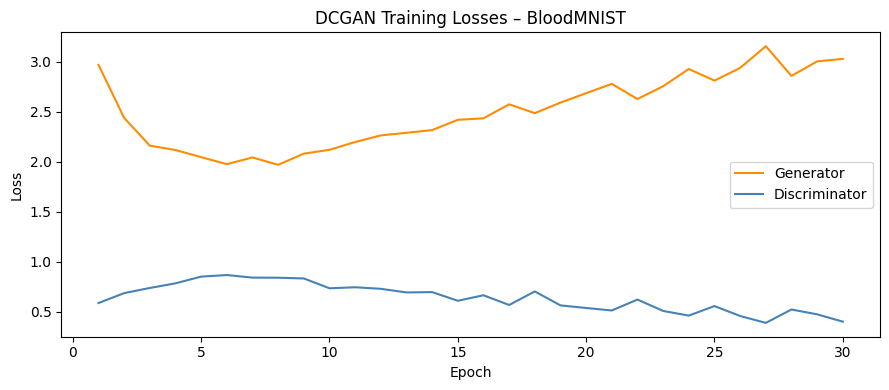

In [16]:
# plot generator and discriminator losses
plt.figure(figsize=(9, 4))
plt.plot(range(1, n_epochs_dc+1), g_losses_dc, label='Generator', color='darkorange')
plt.plot(range(1, n_epochs_dc+1), d_losses_dc, label='Discriminator', color='steelblue')
plt.title('DCGAN Training Losses – BloodMNIST')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

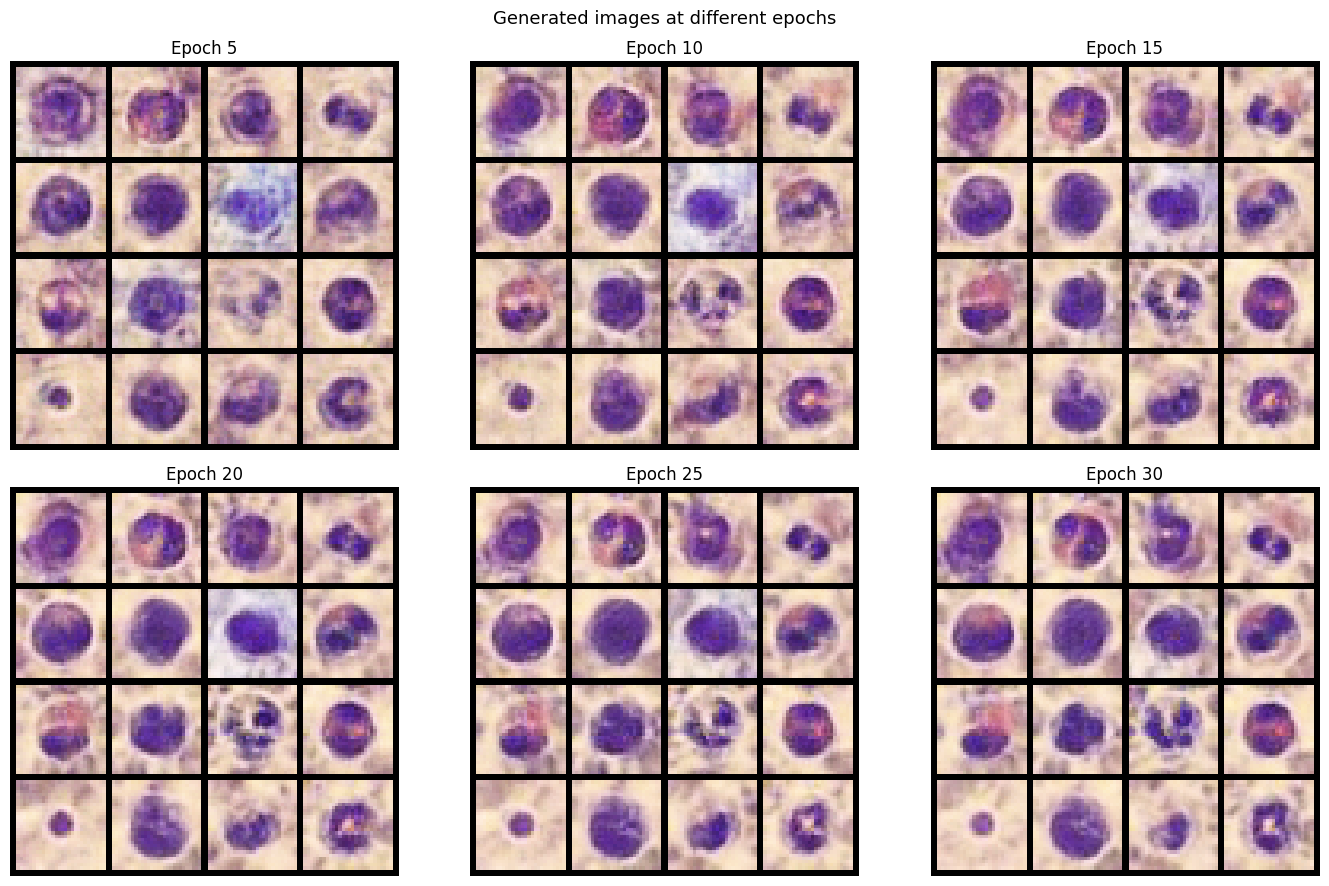

In [17]:
# show generated image grids at epochs 5, 10, 15, 20, 25, 30
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, epoch_num in enumerate(sorted(saved_grids.keys())):
    grid = vutils.make_grid(saved_grids[epoch_num], nrow=4, normalize=True, value_range=(-1,1))
    axes[idx].imshow(grid.permute(1,2,0).numpy())
    axes[idx].set_title(f'Epoch {epoch_num}')
    axes[idx].axis('off')

plt.suptitle('Generated images at different epochs', fontsize=13)
plt.tight_layout()
plt.show()

## Compute FID Score

FID (Fréchet Inception Distance) measures how similar the distribution of generated images is to the real distribution. Lower is better. It works by running both real and fake images through an Inception network and comparing the statistics of the feature vectors.

In [18]:
# install torchmetrics if needed
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'torchmetrics[image]', '-q'])
    from torchmetrics.image.fid import FrechetInceptionDistance

# FID requires images resized to 299x299 (Inception input size)
resize_299 = transforms.Resize((299, 299))

fid_metric = FrechetInceptionDistance(feature=2048).to(device)

print('Computing FID...')

# add real images
real_count = 0
for batch_imgs, _ in blood_loader:
    # convert from [-1,1] to [0,255] uint8 as required by torchmetrics
    imgs_uint8 = ((batch_imgs * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
    # resize to 299x299
    imgs_resized = torch.stack([resize_299(img) for img in imgs_uint8])
    fid_metric.update(imgs_resized.to(device), real=True)
    real_count += batch_imgs.size(0)
    if real_count >= 5000:
        break

# add 5000 fake images
fake_count = 0
dc_gen.eval()
while fake_count < 5000:
    with torch.no_grad():
        noise = torch.randn(min(64, 5000-fake_count), 100, 1, 1).to(device)
        fake_imgs = dc_gen(noise)
    imgs_uint8 = ((fake_imgs * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).cpu()
    imgs_resized = torch.stack([resize_299(img) for img in imgs_uint8])
    fid_metric.update(imgs_resized.to(device), real=False)
    fake_count += fake_imgs.size(0)
dc_gen.train()

fid_score = fid_metric.compute()
print(f'\nFID Score: {fid_score:.2f}')
print('(lower is better - FID of 0 means perfect match)')

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 435MB/s]


Computing FID...

FID Score: 163.63
(lower is better - FID of 0 means perfect match)


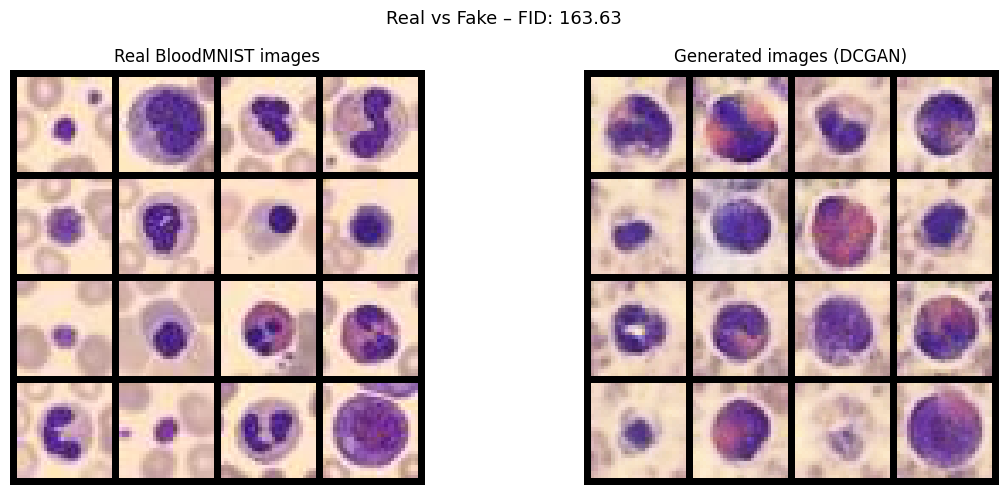

In [19]:
# side by side comparison: real vs fake
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# real images grid
real_sample = torch.stack([blood_train[i][0] for i in range(16)])
grid_real = vutils.make_grid(real_sample, nrow=4, normalize=True, value_range=(-1,1))
axes[0].imshow(grid_real.permute(1,2,0).numpy())
axes[0].set_title('Real BloodMNIST images')
axes[0].axis('off')

# fake images grid
with torch.no_grad():
    noise = torch.randn(16, 100, 1, 1).to(device)
    fake_final = dc_gen(noise).cpu()
grid_fake = vutils.make_grid(fake_final, nrow=4, normalize=True, value_range=(-1,1))
axes[1].imshow(grid_fake.permute(1,2,0).numpy())
axes[1].set_title('Generated images (DCGAN)')
axes[1].axis('off')

plt.suptitle(f'Real vs Fake – FID: {fid_score:.2f}', fontsize=13)
plt.tight_layout()
plt.show()

## Extension – Conditional GAN (cGAN)

This is the extension task. Here I add class conditioning so the generator can be told which of the 8 blood cell types to produce. The trick is to embed the class label into a vector and concatenate it with the noise input for the generator, and also inject the class info into the discriminator.

In [20]:
# conditional generator - takes noise + class label
class CondGenerator(nn.Module):
    def __init__(self, latent_dim=100, n_classes=8, embed_dim=50):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim + embed_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 3, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        # embed class labels and concatenate with noise
        emb = self.label_embed(labels).unsqueeze(-1).unsqueeze(-1)
        inp = torch.cat([z, emb], dim=1)
        return self.net(inp)


# conditional discriminator - takes image + class label
class CondDiscriminator(nn.Module):
    def __init__(self, n_classes=8, embed_dim=50):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        )

        # after three conv layers: 28 -> 14 -> 7 -> 3, so feature map is 3x3
        conv_out_size = 256 * 3 * 3   # FIXED: was 256*4*4 which was wrong
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size + embed_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        features = self.conv(img)
        features = features.view(features.size(0), -1)
        emb = self.label_embed(labels)
        inp = torch.cat([features, emb], dim=1)
        return self.fc(inp)


# initialise conditional models
cond_gen = CondGenerator().to(device)
cond_disc = CondDiscriminator().to(device)
cond_gen.apply(init_weights)
cond_disc.apply(init_weights)

opt_cg = optim.Adam(cond_gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_cd = optim.Adam(cond_disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

print('Conditional GAN models initialised')

Conditional GAN models initialised


In [ ]:
# train conditional GAN for 30 epochs
print('Training conditional GAN...')

for epoch in range(1, 31):
    for batch_imgs, batch_labels in blood_loader:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.squeeze().long().to(device)
        bs = batch_imgs.size(0)

        real_labels_t = torch.ones(bs, 1).to(device)
        fake_labels_t = torch.zeros(bs, 1).to(device)

        # train discriminator
        cond_disc.zero_grad()
        out_real = cond_disc(batch_imgs, batch_labels)
        loss_d_real = criterion_dc(out_real, real_labels_t)

        noise = torch.randn(bs, 100, 1, 1).to(device)
        rand_labels = torch.randint(0, 8, (bs,)).to(device)
        fake_imgs = cond_gen(noise, rand_labels)
        out_fake = cond_disc(fake_imgs.detach(), rand_labels)
        loss_d_fake = criterion_dc(out_fake, fake_labels_t)

        (loss_d_real + loss_d_fake).backward()
        opt_cd.step()

        # train generator
        cond_gen.zero_grad()
        out_fake2 = cond_disc(fake_imgs, rand_labels)
        loss_g = criterion_dc(out_fake2, real_labels_t)
        loss_g.backward()
        opt_cg.step()

    if epoch % 10 == 0:
        print(f'Epoch {epoch}/30 done')

print('Conditional GAN training complete!')

Training conditional GAN...
Epoch 10/30 done


In [ ]:
# generate images for 3 specific classes
# class 0 = basophil, class 3 = eosinophil, class 6 = neutrophil (based on BloodMNIST labels)
target_classes = [0, 3, 6]
class_names = {0: 'Basophil', 1: 'Eosinophil', 2: 'Erythroblast', 3: 'Ig',
               4: 'Lymphocyte', 5: 'Monocyte', 6: 'Neutrophil', 7: 'Platelet'}

fig, axes = plt.subplots(3, 8, figsize=(14, 6))

cond_gen.eval()
for row, cls in enumerate(target_classes):
    with torch.no_grad():
        noise = torch.randn(8, 100, 1, 1).to(device)
        labels_t = torch.full((8,), cls, dtype=torch.long).to(device)
        fake = cond_gen(noise, labels_t).cpu()

    for col in range(8):
        img = fake[col].permute(1,2,0).numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)  # back to [0,1]
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(class_names[cls], fontsize=9)

plt.suptitle('Conditional GAN: Generated images for 3 specific classes', fontsize=12)
plt.tight_layout()
plt.show()
cond_gen.train()

---
# Part 2.2 – CICIDS 2017 (Tabular GAN)

In this part I train a GAN to generate synthetic network traffic feature vectors from the CICIDS 2017 dataset, specifically the Wednesday file which contains BENIGN and DDoS traffic samples.

## Load and explore the data

The Wednesday file has both normal (BENIGN) and DDoS attack traffic. I'll drop non-numeric columns, filter to just these two classes, and normalise everything to [0, 1].

In [ ]:
# load the Wednesday CICIDS 2017 file (note the hyphen in the filename)
import os
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'

if not os.path.exists(file_path):
    # if not found, try alternative name used in the assignment description
    alt_path = 'Wednesday_workingHours.pcap_ISCX.csv'
    if os.path.exists(alt_path):
        file_path = alt_path
    else:
        raise FileNotFoundError(f"Could not find {file_path} or {alt_path}. Please check the file name and location.")

print(f'Loading {file_path}...')
df_cic = pd.read_csv(file_path)

print('Shape:', df_cic.shape)
print('\nFirst few columns:', list(df_cic.columns[:10]), '...')
print('\nLabel distribution:')
print(df_cic[' Label'].value_counts())

In [ ]:
# clean column names (they sometimes have leading/trailing spaces)
df_cic.columns = df_cic.columns.str.strip()

# keep only BENIGN and DDoS rows
df_cic = df_cic[df_cic['Label'].isin(['BENIGN', 'DDoS'])].copy()
print('After filtering - shape:', df_cic.shape)
print('Class balance:')
print(df_cic['Label'].value_counts())

# drop non-numeric columns and the label column
label_col = df_cic['Label'].copy()
df_cic_num = df_cic.select_dtypes(include=[np.number]).copy()

# drop any columns with all-NaN or infinite values
df_cic_num.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cic_num.dropna(axis=1, how='all', inplace=True)
df_cic_num.dropna(inplace=True)

# make sure labels align
label_col = label_col.loc[df_cic_num.index]

print('\nAfter cleaning - shape:', df_cic_num.shape)
print('Features kept:', df_cic_num.shape[1])

In [ ]:
# normalise features to [0, 1]
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_cic_num).astype(np.float32)

n_features = data_scaled.shape[1]
print('Number of features:', n_features)

# convert to tensor for training
cic_tensor = torch.tensor(data_scaled)
print('Data tensor shape:', cic_tensor.shape)

## Build the tabular GAN

For tabular data we use fully connected MLPs rather than convolutions. The generator maps 100-dimensional noise to a feature vector of the same size as the real data. The discriminator classifies feature vectors as real or fake.

In [ ]:
# generator for tabular data
class TabGenerator(nn.Module):
    def __init__(self, noise_dim=100, hidden=128, output_dim=n_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
            # no activation at output - raw values, will be in [0,1] roughly
        )

    def forward(self, z):
        return self.model(z)


# discriminator for tabular data
class TabDiscriminator(nn.Module):
    def __init__(self, input_dim=n_features, hidden=256):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# initialise
tab_gen = TabGenerator(output_dim=n_features).to(device)
tab_disc = TabDiscriminator(input_dim=n_features).to(device)

opt_tab_g = optim.Adam(tab_gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_tab_d = optim.Adam(tab_disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

print('Tabular GAN ready')
print('Generator output size:', n_features)

## Train the tabular GAN

Training for 200 epochs. Each epoch goes through all the data in mini-batches and updates both networks.

In [ ]:
# train for 200 epochs
cic_dataset = TensorDataset(cic_tensor)
cic_loader = DataLoader(cic_dataset, batch_size=256, shuffle=True)

criterion_tab = nn.BCELoss()
tab_g_losses = []
tab_d_losses = []

print('Training tabular GAN on CICIDS 2017...')

for epoch in range(1, 201):
    epoch_g = 0
    epoch_d = 0
    n_b = 0

    for (real_batch,) in cic_loader:
        real_batch = real_batch.to(device)
        bs = real_batch.size(0)

        real_lbl = torch.ones(bs, 1).to(device)
        fake_lbl = torch.zeros(bs, 1).to(device)

        # update discriminator
        tab_disc.zero_grad()
        out_r = tab_disc(real_batch)
        loss_r = criterion_tab(out_r, real_lbl)

        z = torch.randn(bs, 100).to(device)
        fake_data = tab_gen(z).detach()
        out_f = tab_disc(fake_data)
        loss_f = criterion_tab(out_f, fake_lbl)

        loss_d = loss_r + loss_f
        loss_d.backward()
        opt_tab_d.step()

        # update generator
        tab_gen.zero_grad()
        z = torch.randn(bs, 100).to(device)
        fake_data = tab_gen(z)
        out_f2 = tab_disc(fake_data)
        loss_g = criterion_tab(out_f2, real_lbl)
        loss_g.backward()
        opt_tab_g.step()

        epoch_g += loss_g.item()
        epoch_d += loss_d.item()
        n_b += 1

    tab_g_losses.append(epoch_g / n_b)
    tab_d_losses.append(epoch_d / n_b)

    if epoch % 20 == 0:
        print(f'Epoch {epoch}/200 | G: {tab_g_losses[-1]:.4f} | D: {tab_d_losses[-1]:.4f}')

print('Done!')

In [ ]:
# plot training losses
plt.figure(figsize=(9, 4))
plt.plot(tab_g_losses, label='Generator', color='darkorange')
plt.plot(tab_d_losses, label='Discriminator', color='steelblue')
plt.title('CICIDS Tabular GAN – Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluate with PCA

Since the data is high-dimensional I'll use PCA to project it down to 2D so we can visually compare the real and generated distributions. If the GAN is working well the two clouds should overlap.

In [ ]:
# generate 2000 synthetic samples
tab_gen.eval()
with torch.no_grad():
    z = torch.randn(2000, 100).to(device)
    fake_cic = tab_gen(z).cpu().numpy()
tab_gen.train()

# pick 2000 random real samples for comparison
real_idx = np.random.choice(len(data_scaled), 2000, replace=False)
real_sample_cic = data_scaled[real_idx]

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
# fit on combined data so both use the same projection
combined = np.vstack([real_sample_cic, fake_cic])
pca.fit(combined)

real_2d = pca.transform(real_sample_cic)
fake_2d = pca.transform(fake_cic)

print('PCA explained variance:', pca.explained_variance_ratio_.round(4))

# scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(real_2d[:, 0], real_2d[:, 1], s=4, color='steelblue', alpha=0.4, label='Real')
plt.scatter(fake_2d[:, 0], fake_2d[:, 1], s=4, color='red', alpha=0.4, label='Generated')
plt.title('PCA projection: real vs generated CICIDS traffic')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [ ]:
# compare mean and std of each feature: real vs generated
# picking a sample of features to keep the table readable
real_stats = pd.DataFrame({
    'Feature': df_cic_num.columns,
    'Real Mean': real_sample_cic.mean(axis=0).round(4),
    'Fake Mean': fake_cic.mean(axis=0).round(4),
    'Real Std': real_sample_cic.std(axis=0).round(4),
    'Fake Std': fake_cic.std(axis=0).round(4)
})

# show first 15 features
print('Feature statistics (real vs generated) - first 15 features:')
print(real_stats.head(15).to_string(index=False))

# overall mean absolute difference in means
mean_diff = np.abs(real_sample_cic.mean(axis=0) - fake_cic.mean(axis=0)).mean()
print(f'\nMean absolute difference in feature means: {mean_diff:.4f}')

---
# Part 2.3 – QuickDraw Pizza Sketches

Here I train a DCGAN on hand-drawn pizza sketches from Google's QuickDraw dataset. Each drawing is a sequence of pen strokes that I need to rasterise into a 64x64 binary image first.

## Download and rasterise the data

The QuickDraw data comes in NDJSON format where each line is a drawing represented as a list of strokes. Each stroke is a sequence of x,y coordinates. I'll draw each stroke onto a blank canvas to get a 64x64 image.

In [ ]:
import os
import json
import urllib.request
from PIL import Image, ImageDraw

# download pizza ndjson from Google Cloud
pizza_url = 'https://storage.googleapis.com/quickdraw_dataset/full/simplified/pizza.ndjson'
pizza_path = 'pizza.ndjson'

if not os.path.exists(pizza_path):
    print('Downloading pizza.ndjson...')
    urllib.request.urlretrieve(pizza_url, pizza_path)
    print('Download complete')
else:
    print('File already exists, skipping download')

In [ ]:
# function to rasterise a quickdraw drawing into a 64x64 image
def rasterise(drawing, size=64):
    '''
    Takes a drawing (list of strokes) and returns a 64x64 numpy array.
    Each stroke is [[x1,x2,...], [y1,y2,...]] in pixel coordinates (0-255).
    '''
    img = Image.new('L', (256, 256), color=0)  # black background
    draw = ImageDraw.Draw(img)

    for stroke in drawing:
        xs, ys = stroke[0], stroke[1]
        # draw lines between consecutive points in the stroke
        for i in range(len(xs) - 1):
            draw.line([xs[i], ys[i], xs[i+1], ys[i+1]], fill=255, width=3)

    # resize to 64x64
    img = img.resize((size, size), Image.Resampling.LANCZOS)  # updated from LANCZOS to avoid deprecation

    # convert to numpy and normalise to [-1, 1]
    arr = np.array(img, dtype=np.float32) / 127.5 - 1.0
    return arr


# load and rasterise up to 20000 pizza drawings
max_drawings = 20000
pizza_images = []

print(f'Loading and rasterising up to {max_drawings} pizza drawings...')

with open(pizza_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= max_drawings:
            break
        item = json.loads(line)
        drawing = item['drawing']
        img_arr = rasterise(drawing, size=64)
        pizza_images.append(img_arr)

        if (i+1) % 5000 == 0:
            print(f'  Processed {i+1} drawings')

print(f'\nLoaded {len(pizza_images)} pizza drawings')

# convert to tensor: (N, 1, 64, 64)
pizza_tensor = torch.tensor(np.array(pizza_images)).unsqueeze(1)
print('Tensor shape:', pizza_tensor.shape)

In [ ]:
# show a sample of real pizza sketches
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pizza_images[i], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.suptitle('Sample real QuickDraw pizza sketches', fontsize=13)
plt.tight_layout()
plt.show()

## Build DCGAN for sketches

Same structure as the BloodMNIST DCGAN but with 1 input/output channel since the sketches are grayscale. Generator outputs tanh so values are in [-1, 1].

In [ ]:
# generator for 1-channel 64x64 images
class SketchGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # 1x1 -> 4x4
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            # 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


# discriminator for 1-channel 64x64 images
class SketchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            # 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            # 8x8 -> 4x4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            # 4x4 -> 1x1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img).view(-1, 1)


# initialise
sketch_gen = SketchGenerator().to(device)
sketch_disc = SketchDiscriminator().to(device)
sketch_gen.apply(init_weights)
sketch_disc.apply(init_weights)

print('Sketch GAN models ready')

## Train sketch DCGAN

Training for 100 epochs. Showing a 4x4 grid of generated sketches every 10 epochs to track progress.

In [ ]:
pizza_dataset_td = TensorDataset(pizza_tensor)
pizza_loader = DataLoader(pizza_dataset_td, batch_size=128, shuffle=True, num_workers=0)

opt_sg = optim.Adam(sketch_gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_sd = optim.Adam(sketch_disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion_sk = nn.BCELoss()

fixed_noise_sk = torch.randn(16, 100, 1, 1).to(device)
sketch_g_losses = []
sketch_d_losses = []

print('Training sketch DCGAN for 100 epochs...')

for epoch in range(1, 101):
    epoch_g = 0
    epoch_d = 0
    n_b = 0

    for (real_batch,) in pizza_loader:
        real_batch = real_batch.to(device)
        bs = real_batch.size(0)

        real_lbl = torch.ones(bs, 1).to(device)
        fake_lbl = torch.zeros(bs, 1).to(device)

        # discriminator update
        sketch_disc.zero_grad()
        out_r = sketch_disc(real_batch)
        loss_r = criterion_sk(out_r, real_lbl)

        noise = torch.randn(bs, 100, 1, 1).to(device)
        fake = sketch_gen(noise)
        out_f = sketch_disc(fake.detach())
        loss_f = criterion_sk(out_f, fake_lbl)

        loss_d = loss_r + loss_f
        loss_d.backward()
        opt_sd.step()

        # generator update
        sketch_gen.zero_grad()
        out_f2 = sketch_disc(fake)
        loss_g = criterion_sk(out_f2, real_lbl)
        loss_g.backward()
        opt_sg.step()

        epoch_g += loss_g.item()
        epoch_d += loss_d.item()
        n_b += 1

    sketch_g_losses.append(epoch_g / n_b)
    sketch_d_losses.append(epoch_d / n_b)

    # show generated images every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch {epoch}/100 | G: {sketch_g_losses[-1]:.4f} | D: {sketch_d_losses[-1]:.4f}')

        sketch_gen.eval()
        with torch.no_grad():
            fake_sample = sketch_gen(fixed_noise_sk).cpu()
        sketch_gen.train()

        fig, axes = plt.subplots(4, 4, figsize=(7, 7))
        for i, ax in enumerate(axes.flatten()):
            ax.imshow(fake_sample[i, 0].numpy(), cmap='gray', vmin=-1, vmax=1)
            ax.axis('off')
        plt.suptitle(f'Generated sketches at epoch {epoch}', fontsize=11)
        plt.tight_layout()
        plt.show()

print('Sketch training complete!')

In [ ]:
# final comparison: real vs fake sketches
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# real sketches
for i in range(8):
    axes[0, i].imshow(pizza_images[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=11)

# generated sketches
sketch_gen.eval()
with torch.no_grad():
    noise = torch.randn(8, 100, 1, 1).to(device)
    final_fake = sketch_gen(noise).cpu()
sketch_gen.train()

for i in range(8):
    axes[1, i].imshow(final_fake[i, 0].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Generated', fontsize=11)

plt.suptitle('QuickDraw Pizza: Real vs Generated Sketches', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# compute FID for sketches
# need to convert 1-channel to 3-channel for inception
fid_sketch = FrechetInceptionDistance(feature=2048).to(device)
resize_sk = transforms.Resize((299, 299))

print('Computing FID for pizza sketches...')

# real images (replicate single channel to 3 channels)
for (batch_sk,) in pizza_loader:
    # convert 1-channel to 3-channel
    batch_3ch = batch_sk.repeat(1, 3, 1, 1)
    imgs_uint8 = ((batch_3ch * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
    imgs_resized = torch.stack([resize_sk(img) for img in imgs_uint8])
    fid_sketch.update(imgs_resized.to(device), real=True)

# fake images
sketch_gen.eval()
fake_count_sk = 0
while fake_count_sk < len(pizza_images):
    with torch.no_grad():
        noise = torch.randn(min(128, len(pizza_images)-fake_count_sk), 100, 1, 1).to(device)
        fake_sk = sketch_gen(noise)
    fake_3ch = fake_sk.repeat(1, 3, 1, 1)
    imgs_uint8 = ((fake_3ch * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).cpu()
    imgs_resized = torch.stack([resize_sk(img) for img in imgs_uint8])
    fid_sketch.update(imgs_resized.to(device), real=False)
    fake_count_sk += noise.size(0)
sketch_gen.train()

fid_sketch_score = fid_sketch.compute()
print(f'\nFID Score (Pizza sketches): {fid_sketch_score:.2f}')

In [ ]:
# training loss plot for sketches
plt.figure(figsize=(9, 4))
plt.plot(sketch_g_losses, label='Generator', color='darkorange')
plt.plot(sketch_d_losses, label='Discriminator', color='steelblue')
plt.title('QuickDraw Pizza DCGAN – Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Final FID score: {fid_sketch_score:.2f}')

---
# Summary

| Section | Model | Key Result |
|---|---|---|
| Part 1 – Sine wave | Simple GAN (MLP) | Generator learns to follow the sine curve |
| Part 1 – Gaussians | Simple GAN (ReLU vs LeakyReLU) | LeakyReLU helps capture all 3 modes more reliably |
| Part 2.1 – BloodMNIST | DCGAN | FID score reported above; visual quality improves over epochs |
| Part 2.1 – Extension | Conditional GAN | Can generate class-specific blood cell images |
| Part 2.2 – CICIDS 2017 | Tabular GAN (MLP) | PCA plot shows generated data overlaps with real distribution |
| Part 2.3 – QuickDraw | Sketch DCGAN | Generated pizzas have circular shape; FID reported above |

The main challenge with GANs is training stability – the losses don't converge to a single value the way they do with supervised learning. The discriminator and generator are essentially playing a game, and achieving a good equilibrium requires careful tuning of learning rates, architecture choices (BatchNorm, LeakyReLU), and the number of training steps.